# ZOIDBERG2.0 - Step 1: Data Analysis & Integrity Check

**Project:** Medical Imaging / Computer Aided Diagnosis - Pneumonia Detection  
**Author:** ML Architecture Team  
**Date:** January 2026  

---

## Objectives

1. **Load and inspect the 3 datasets** (Dataset1, Dataset2, Dataset3_Tuning)
2. **Data integrity checks:**
   - Verify image file formats and readability
   - Check for corrupted or missing images
   - Validate directory structure and labeling
3. **Exploratory Data Analysis (EDA):**
   - Class distribution analysis
   - Image dimension analysis
   - Pixel intensity statistics
   - Sample visualization
4. **Dataset comparison:**
   - Compare the 3 datasets for consistency
   - Identify potential biases or imbalances
5. **Generate data quality report**

---

## Dataset Strategy

- **Dataset 1 & 2:** Training and validation (will compare train-test split vs cross-validation)
- **Dataset 3:** Reserved exclusively for hyperparameter tuning and final model selection

---

In [4]:
# Import Required Libraries
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm
import yaml

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Add src to path for custom modules
project_root = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

print("✓ Libraries imported successfully")
print(f"✓ Project root: {project_root}")

✓ Libraries imported successfully
✓ Project root: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19


In [5]:
# Load Configuration
config_path = project_root / 'config' / 'config.yaml'

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("✓ Configuration loaded")
print(f"\nProject: {config['project']['name']} v{config['project']['version']}")
print(f"Classification Task: {config['classification']['task']}")
print(f"Target Image Size: {config['image']['target_size']}")

✓ Configuration loaded

Project: ZOIDBERG2.0 v2.0.0
Classification Task: binary
Target Image Size: [224, 224]


In [6]:
# Define Dataset Paths
dataset_paths = {
    'dataset1': project_root / config['paths']['dataset1'],
    'dataset2': project_root / config['paths']['dataset2'],
    'dataset3_tuning': project_root / config['paths']['dataset3_tuning']
}

print("Dataset Paths:")
for name, path in dataset_paths.items():
    exists = "✓" if path.exists() else "✗"
    print(f"  {exists} {name}: {path}")

Dataset Paths:
  ✓ dataset1: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\data\raw\dataset1
  ✓ dataset2: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\data\raw\dataset2
  ✓ dataset3_tuning: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\data\raw\dataset3_tuning


---
## 1. Dataset Structure Analysis

We'll analyze the directory structure to understand how the data is organized.

In [7]:
def analyze_dataset_structure(dataset_path, dataset_name):
    """
    Analyze the directory structure of a dataset.
    
    Args:
        dataset_path (Path): Path to the dataset
        dataset_name (str): Name of the dataset for reporting
    
    Returns:
        dict: Dictionary containing structure information
    """
    print(f"\n{'='*60}")
    print(f"Analyzing: {dataset_name}")
    print(f"{'='*60}")
    
    if not dataset_path.exists():
        print(f"⚠️  WARNING: Dataset path does not exist: {dataset_path}")
        return None
    
    structure = {
        'name': dataset_name,
        'path': str(dataset_path),
        'exists': True,
        'classes': {},
        'total_images': 0,
        'file_extensions': set()
    }
    
    # Check if dataset has subdirectories (class folders)
    subdirs = [d for d in dataset_path.iterdir() if d.is_dir()]
    
    if len(subdirs) == 0:
        print("📁 No class subdirectories found. Looking for images in root...")
        image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
        images = [f for f in dataset_path.iterdir() 
                 if f.is_file() and f.suffix.lower() in image_extensions]
        
        if len(images) > 0:
            print(f"   Found {len(images)} images in root directory")
            print("   ⚠️  WARNING: Images should be organized in class subdirectories")
            structure['total_images'] = len(images)
        else:
            print("   ⚠️  No images found. Please place your datasets here.")
    else:
        print(f"📁 Found {len(subdirs)} class directories:")
        
        for class_dir in sorted(subdirs):
            class_name = class_dir.name
            
            # Count images in this class
            image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.dcm'}
            images = [f for f in class_dir.rglob('*') 
                     if f.is_file() and f.suffix.lower() in image_extensions]
            
            num_images = len(images)
            structure['classes'][class_name] = num_images
            structure['total_images'] += num_images
            
            # Track file extensions
            for img in images:
                structure['file_extensions'].add(img.suffix.lower())
            
            print(f"   • {class_name}: {num_images} images")
    
    structure['file_extensions'] = list(structure['file_extensions'])
    
    print(f"\n📊 Total Images: {structure['total_images']}")
    if structure['file_extensions']:
        print(f"📄 File Extensions: {', '.join(structure['file_extensions'])}")
    
    return structure


# Analyze all three datasets
dataset_structures = {}
for name, path in dataset_paths.items():
    dataset_structures[name] = analyze_dataset_structure(path, name)


Analyzing: dataset1
📁 Found 2 class directories:
   • NORMAL: 1341 images
   • PNEUMONIA: 3875 images

📊 Total Images: 5216
📄 File Extensions: .jpeg

Analyzing: dataset2
📁 Found 2 class directories:
   • NORMAL: 8 images
   • PNEUMONIA: 8 images

📊 Total Images: 16
📄 File Extensions: .jpeg

Analyzing: dataset3_tuning
📁 Found 2 class directories:
   • NORMAL: 234 images
   • PNEUMONIA: 390 images

📊 Total Images: 624
📄 File Extensions: .jpeg


In [ ]:
# Create summary DataFrame
summary_data = []

for name, structure in dataset_structures.items():
    if structure and structure['exists']:
        summary_data.append({
            'Dataset': name,
            'Total Images': structure['total_images'],
            'Classes': len(structure['classes']),
            'Class Names': ', '.join(structure['classes'].keys()) if structure['classes'] else 'N/A',
            'Extensions': ', '.join(structure['file_extensions'])
        })

if summary_data:
    summary_df = pd.DataFrame(summary_data)
    print("\n" + "="*80)
    print("DATASET SUMMARY")
    print("="*80)
    display(summary_df)
else:
    print("\n⚠️  No valid datasets found. Please add your X-ray image datasets to:")
    for name, path in dataset_paths.items():
        print(f"   • {path}")
        ##


DATASET SUMMARY


,Dataset,Total Images,Classes,Class Names,Extensions
0,dataset1,5216,2,"NORMAL, PNEUMONIA",.jpeg
1,dataset2,16,2,"NORMAL, PNEUMONIA",.jpeg
2,dataset3_tuning,624,2,"NORMAL, PNEUMONIA",.jpeg


## 1.b Real Label Analysis (Binary vs Multiclass)

In [9]:
def analyze_real_label_distribution(dataset_path, dataset_name):
    """
    Analyze real labels based on folder names and filenames.
    
    Physical structure may be binary (NORMAL / PNEUMONIA),
    while true medical labels may be multiclass
    (NORMAL / BACTERIA / VIRUS).
    """
    print(f"\n{'='*60}")
    print(f"Real Label Analysis: {dataset_name}")
    print(f"{'='*60}")
    
    if not dataset_path.exists():
        print(f"⚠️  WARNING: Dataset path does not exist: {dataset_path}")
        return None
    
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.dcm'}
    
    results = {
        'dataset': dataset_name,
        'binary_distribution': {'NORMAL': 0, 'PNEUMONIA': 0},
        'multiclass_distribution': {'NORMAL': 0, 'BACTERIA': 0, 'VIRUS': 0},
        'unknown_multiclass': 0,
        'unknown_examples': [],
        'total_images': 0
    }
    
    class_dirs = [d for d in dataset_path.iterdir() if d.is_dir()]
    
    for class_dir in class_dirs:
        class_name = class_dir.name.upper()
        
        images = [f for f in class_dir.rglob('*')
                  if f.is_file() and f.suffix.lower() in image_extensions]
        
        for img_path in images:
            filename = img_path.name.upper()
            results['total_images'] += 1
            
            # Binary view
            if 'NORMAL' in class_name:
                results['binary_distribution']['NORMAL'] += 1
            else:
                results['binary_distribution']['PNEUMONIA'] += 1
            
            # Multiclass view
            if 'NORMAL' in class_name:
                results['multiclass_distribution']['NORMAL'] += 1
            elif 'BACTERIA' in filename or 'BACTERIAL' in filename:
                results['multiclass_distribution']['BACTERIA'] += 1
            elif 'VIRUS' in filename or 'VIRAL' in filename:
                results['multiclass_distribution']['VIRUS'] += 1
            else:
                results['unknown_multiclass'] += 1
                if len(results['unknown_examples']) < 5:
                    results['unknown_examples'].append(img_path.name)
    
    print("Binary distribution:")
    for cls, count in results['binary_distribution'].items():
        print(f"   • {cls}: {count}")
    
    print("\nMulticlass distribution:")
    for cls, count in results['multiclass_distribution'].items():
        print(f"   • {cls}: {count}")
    
    if results['unknown_multiclass'] > 0:
        print(f"\n⚠️  Unknown multiclass labels: {results['unknown_multiclass']}")
        print("Examples:")
        for ex in results['unknown_examples']:
            print(f"   • {ex}")
    else:
        print("\n✓ All pneumonia filenames could be mapped to BACTERIA or VIRUS")
    
    return results

real_label_results = {}
for name, path in dataset_paths.items():
    real_label_results[name] = analyze_real_label_distribution(path, name)


Real Label Analysis: dataset1
Binary distribution:
   • NORMAL: 1341
   • PNEUMONIA: 3875

Multiclass distribution:
   • NORMAL: 1341
   • BACTERIA: 2530
   • VIRUS: 1345

✓ All pneumonia filenames could be mapped to BACTERIA or VIRUS

Real Label Analysis: dataset2
Binary distribution:
   • NORMAL: 8
   • PNEUMONIA: 8

Multiclass distribution:
   • NORMAL: 8
   • BACTERIA: 8
   • VIRUS: 0

✓ All pneumonia filenames could be mapped to BACTERIA or VIRUS

Real Label Analysis: dataset3_tuning
Binary distribution:
   • NORMAL: 234
   • PNEUMONIA: 390

Multiclass distribution:
   • NORMAL: 234
   • BACTERIA: 242
   • VIRUS: 148

✓ All pneumonia filenames could be mapped to BACTERIA or VIRUS


In [10]:
real_summary_data = []

for name, result in real_label_results.items():
    if result is not None:
        real_summary_data.append({
            'Dataset': name,
            'Total Images': result['total_images'],
            'Binary Classes': ', '.join([f"{k}: {v}" for k, v in result['binary_distribution'].items()]),
            'Multiclass Classes': ', '.join([f"{k}: {v}" for k, v in result['multiclass_distribution'].items()]),
            'Unknown Multiclass': result['unknown_multiclass']
        })

real_summary_df = pd.DataFrame(real_summary_data)

print("\n" + "="*80)
print("REAL LABEL SUMMARY")
print("="*80)
display(real_summary_df)


REAL LABEL SUMMARY


,Dataset,Total Images,Binary Classes,Multiclass Classes,Unknown Multiclass
0,dataset1,5216,"NORMAL: 1341, PNEUMONIA: 3875","NORMAL: 1341, BACTERIA: 2530, VIRUS: 1345",0
1,dataset2,16,"NORMAL: 8, PNEUMONIA: 8","NORMAL: 8, BACTERIA: 8, VIRUS: 0",0
2,dataset3_tuning,624,"NORMAL: 234, PNEUMONIA: 390","NORMAL: 234, BACTERIA: 242, VIRUS: 148",0


---
## 2. Class Distribution Analysis

Analyzing class balance to detect potential bias issues.

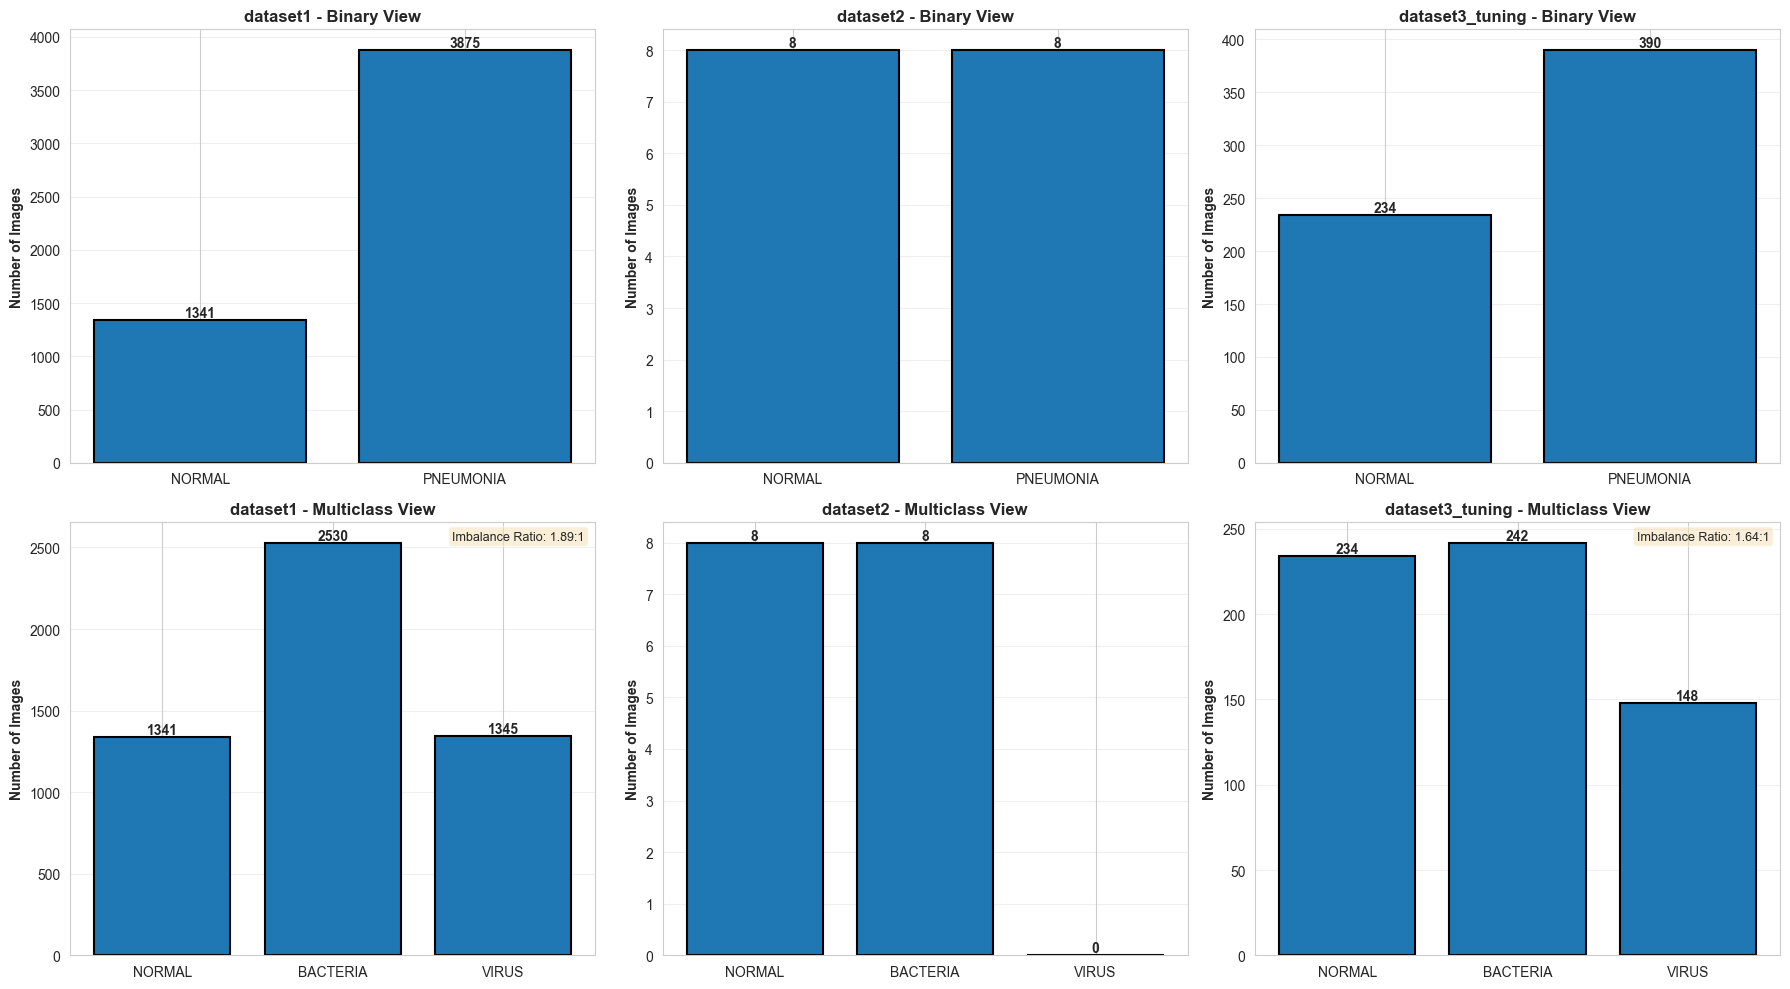

✓ Real class distribution plot saved to: reports/figures/real_class_distribution.png


In [11]:
def plot_real_class_distribution(real_label_results):
    """
    Visualize both binary and multiclass distributions across datasets.
    """
    valid_results = {k: v for k, v in real_label_results.items() if v is not None}
    
    if not valid_results:
        print("⚠️  No valid datasets found for visualization.")
        return
    
    num_datasets = len(valid_results)
    fig, axes = plt.subplots(2, num_datasets, figsize=(6 * num_datasets, 10))
    
    if num_datasets == 1:
        axes = np.array(axes).reshape(2, 1)
    
    for col, (name, result) in enumerate(valid_results.items()):
        # Binary
        ax1 = axes[0, col]
        binary_classes = list(result['binary_distribution'].keys())
        binary_counts = list(result['binary_distribution'].values())
        bars1 = ax1.bar(binary_classes, binary_counts, edgecolor='black', linewidth=1.5)
        
        for bar in bars1:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}', ha='center', va='bottom', fontweight='bold')
        
        ax1.set_title(f'{name} - Binary View', fontweight='bold')
        ax1.set_ylabel('Number of Images', fontweight='bold')
        ax1.grid(axis='y', alpha=0.3)
        
        # Multiclass
        ax2 = axes[1, col]
        multi_classes = list(result['multiclass_distribution'].keys())
        multi_counts = list(result['multiclass_distribution'].values())
        bars2 = ax2.bar(multi_classes, multi_counts, edgecolor='black', linewidth=1.5)
        
        for bar in bars2:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}', ha='center', va='bottom', fontweight='bold')
        
        ax2.set_title(f'{name} - Multiclass View', fontweight='bold')
        ax2.set_ylabel('Number of Images', fontweight='bold')
        ax2.grid(axis='y', alpha=0.3)
        
        if len(multi_counts) > 1 and min(multi_counts) > 0:
            imbalance_ratio = max(multi_counts) / min(multi_counts)
            ax2.text(0.98, 0.98, f'Imbalance Ratio: {imbalance_ratio:.2f}:1',
                     transform=ax2.transAxes,
                     ha='right', va='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                     fontsize=9)
    
    plt.tight_layout()
    plt.savefig(project_root / 'reports' / 'figures' / 'real_class_distribution.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Real class distribution plot saved to: reports/figures/real_class_distribution.png")

plot_real_class_distribution(real_label_results)

---
## 3. Image Integrity & Quality Check

Checking for corrupted images, unusual dimensions, and pixel value ranges.

In [12]:
def check_image_integrity(dataset_path, dataset_name, sample_size=100):
    """
    Check image integrity and collect statistics.
    
    Args:
        dataset_path (Path): Path to dataset
        dataset_name (str): Name of dataset
        sample_size (int): Number of images to sample for detailed analysis
    
    Returns:
        dict: Dictionary containing integrity check results
    """
    print(f"\n{'='*60}")
    print(f"Image Integrity Check: {dataset_name}")
    print(f"{'='*60}")
    
    if not dataset_path.exists():
        print(f"⚠️  Dataset path does not exist.")
        return None
    
    # Collect all image paths
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
    all_images = [f for f in dataset_path.rglob('*') 
                  if f.is_file() and f.suffix.lower() in image_extensions]
    
    if len(all_images) == 0:
        print("⚠️  No images found for integrity check.")
        return None
    
    # Sample images for detailed analysis
    sample_images = np.random.choice(all_images, 
                                    size=min(sample_size, len(all_images)), 
                                    replace=False)
    
    results = {
        'total_images': len(all_images),
        'sampled': len(sample_images),
        'corrupted': 0,
        'dimensions': [],
        'pixel_stats': [],
        'color_modes': {},
        'errors': []
    }
    
    print(f"Analyzing {len(sample_images)} sample images...")
    
    for img_path in tqdm(sample_images, desc="Checking images"):
        try:
            # Try to open with PIL
            with Image.open(img_path) as img:
                # Get dimensions
                results['dimensions'].append(img.size)
                
                # Get color mode
                mode = img.mode
                results['color_modes'][mode] = results['color_modes'].get(mode, 0) + 1
                
                # Convert to numpy array for pixel analysis
                img_array = np.array(img)
                
                results['pixel_stats'].append({
                    'mean': np.mean(img_array),
                    'std': np.std(img_array),
                    'min': np.min(img_array),
                    'max': np.max(img_array)
                })
        
        except Exception as e:
            results['corrupted'] += 1
            results['errors'].append({
                'file': str(img_path),
                'error': str(e)
            })
    
    # Analyze dimensions
    if results['dimensions']:
        widths = [d[0] for d in results['dimensions']]
        heights = [d[1] for d in results['dimensions']]
        
        print(f"\n📐 Dimension Statistics:")
        print(f"   Width:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.1f}")
        print(f"   Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.1f}")
        print(f"   Unique dimensions: {len(set(results['dimensions']))}")
    
    # Pixel statistics
    if results['pixel_stats']:
        mean_vals = [s['mean'] for s in results['pixel_stats']]
        print(f"\n📊 Pixel Value Statistics:")
        print(f"   Mean: {np.mean(mean_vals):.2f} ± {np.std(mean_vals):.2f}")
        print(f"   Range: [{np.mean([s['min'] for s in results['pixel_stats']]):.1f}, "
              f"{np.mean([s['max'] for s in results['pixel_stats']]):.1f}]")
    
    # Color modes
    print(f"\n🎨 Color Modes:")
    for mode, count in results['color_modes'].items():
        print(f"   {mode}: {count} images ({count/len(sample_images)*100:.1f}%)")
    
    # Report issues
    if results['corrupted'] > 0:
        print(f"\n❌ Corrupted/Unreadable Images: {results['corrupted']}")
        print("   First few errors:")
        for error in results['errors'][:3]:
            print(f"   • {Path(error['file']).name}: {error['error']}")
    else:
        print(f"\n✓ All sampled images are readable (0 corrupted)")
    
    return results


# Run integrity checks
integrity_results = {}
for name, path in dataset_paths.items():
    integrity_results[name] = check_image_integrity(path, name, sample_size=100)


Image Integrity Check: dataset1
Analyzing 100 sample images...


Checking images: 100%|██████████| 100/100 [00:02<00:00, 47.91it/s]



📐 Dimension Statistics:
   Width:  min=724, max=2144, mean=1303.3
   Height: min=286, max=2169, mean=957.8
   Unique dimensions: 100

📊 Pixel Value Statistics:
   Mean: 125.05 ± 17.43
   Range: [0.1, 253.8]

🎨 Color Modes:
   L: 96 images (96.0%)
   RGB: 4 images (4.0%)

✓ All sampled images are readable (0 corrupted)

Image Integrity Check: dataset2
Analyzing 16 sample images...


Checking images: 100%|██████████| 16/16 [00:00<00:00, 37.98it/s]



📐 Dimension Statistics:
   Width:  min=968, max=1776, mean=1348.2
   Height: min=592, max=1416, mean=1002.9
   Unique dimensions: 16

📊 Pixel Value Statistics:
   Mean: 124.94 ± 20.21
   Range: [0.0, 255.0]

🎨 Color Modes:
   L: 16 images (100.0%)

✓ All sampled images are readable (0 corrupted)

Image Integrity Check: dataset3_tuning
Analyzing 100 sample images...


Checking images: 100%|██████████| 100/100 [00:02<00:00, 36.17it/s]


📐 Dimension Statistics:
   Width:  min=792, max=2446, mean=1395.6
   Height: min=464, max=2224, mean=1019.6
   Unique dimensions: 98

📊 Pixel Value Statistics:
   Mean: 123.30 ± 17.72
   Range: [0.0, 254.9]

🎨 Color Modes:
   L: 100 images (100.0%)

✓ All sampled images are readable (0 corrupted)


---
## 4. Sample Image Visualization

Visualizing sample images from each class and dataset.


Visualizing samples from: dataset1


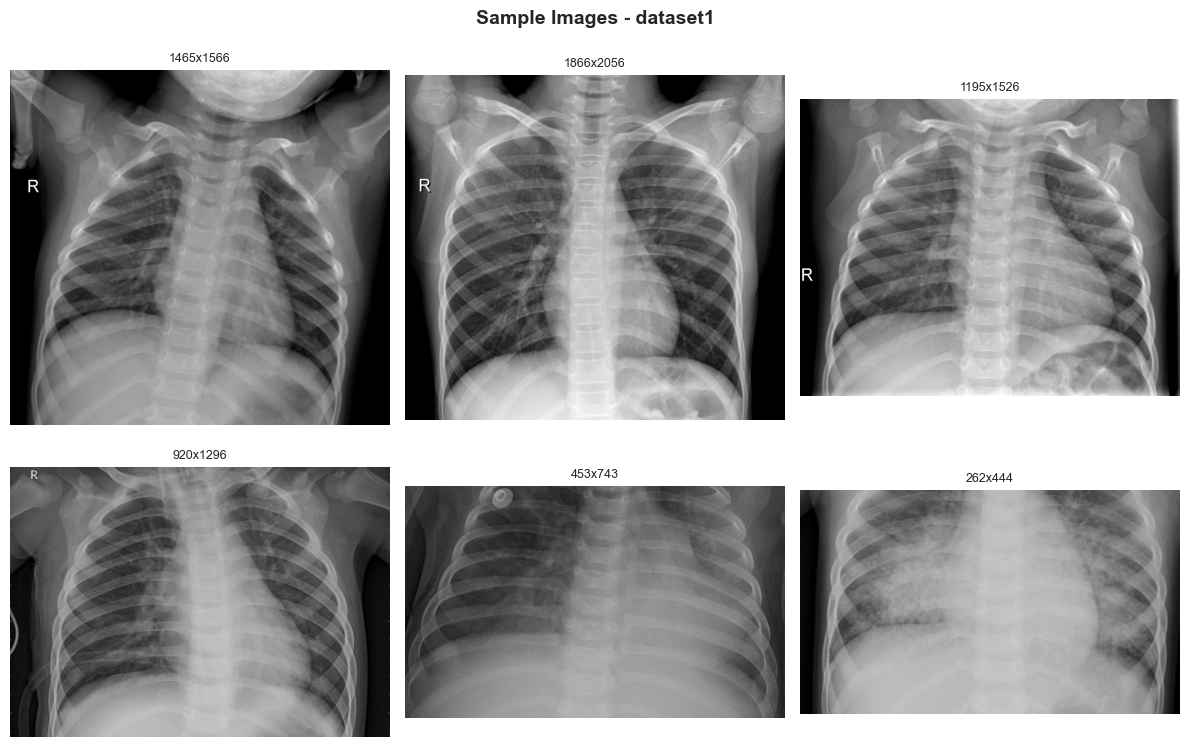

✓ Sample visualization saved to: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\reports\figures\samples_dataset1.png

Visualizing samples from: dataset2


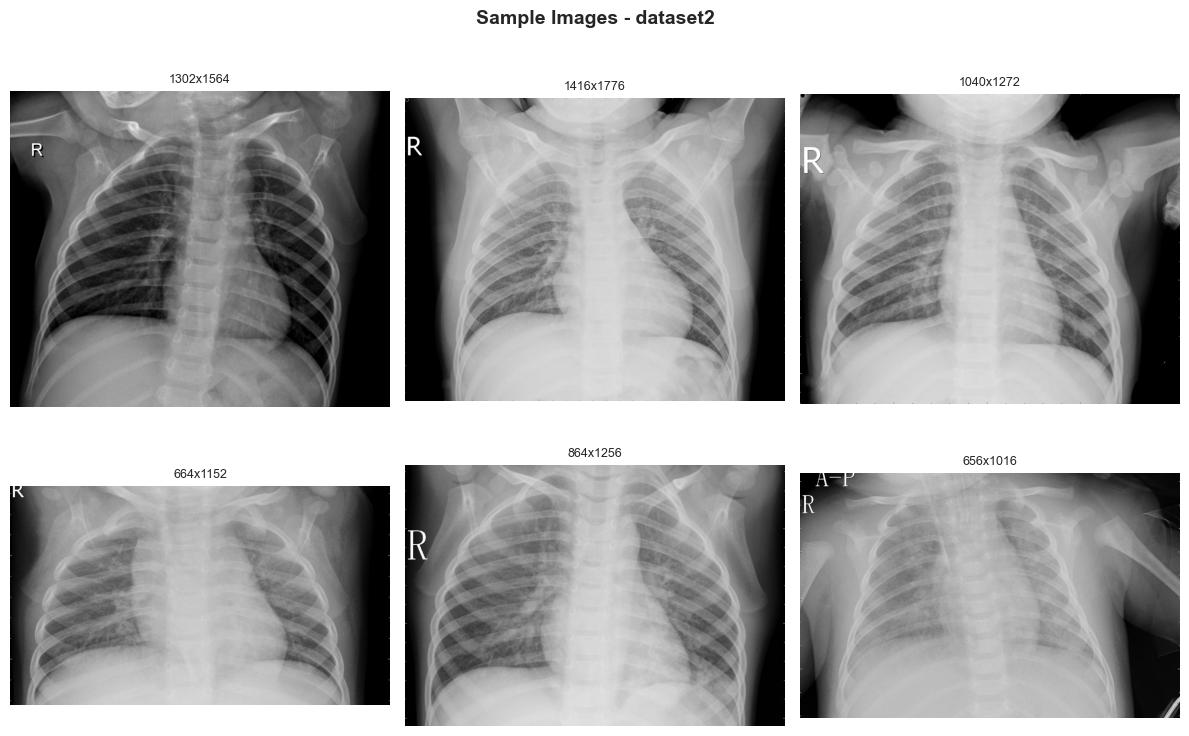

✓ Sample visualization saved to: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\reports\figures\samples_dataset2.png

Visualizing samples from: dataset3_tuning


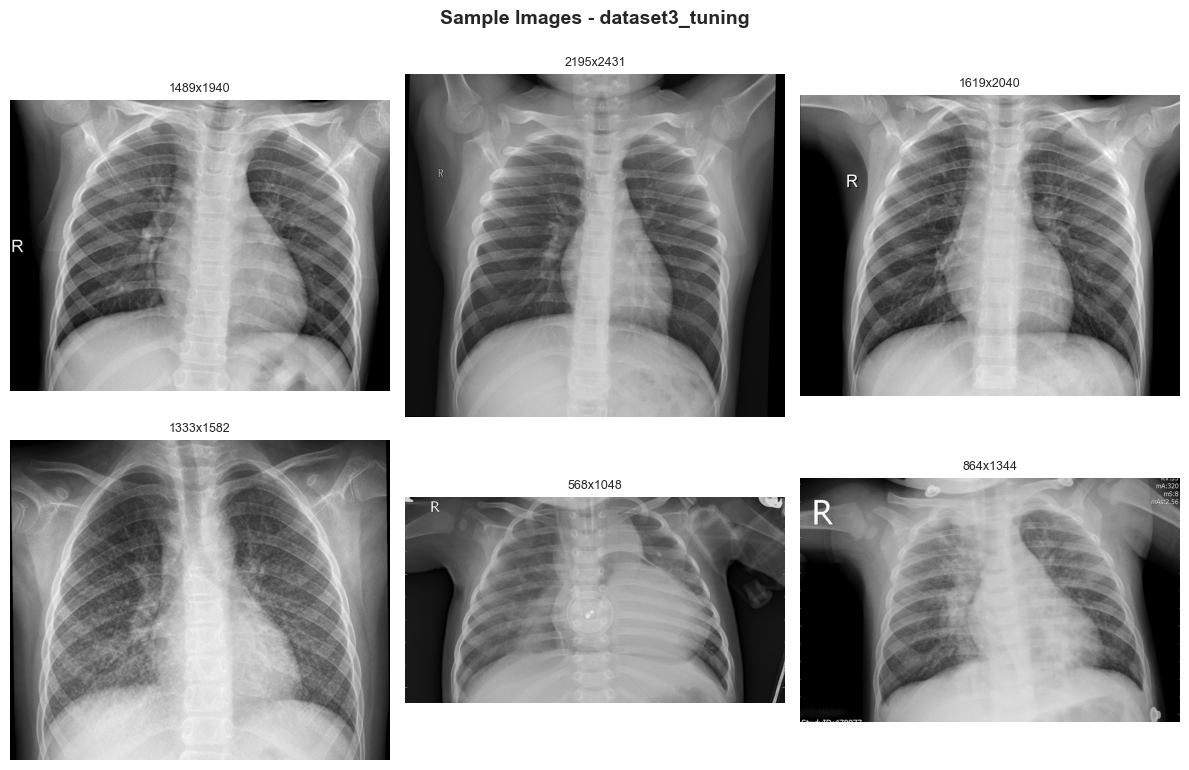

✓ Sample visualization saved to: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\reports\figures\samples_dataset3_tuning.png


In [13]:
def visualize_samples(dataset_path, dataset_name, samples_per_class=3):
    """
    Visualize random samples from each class.
    """
    print(f"\nVisualizing samples from: {dataset_name}")
    
    if not dataset_path.exists():
        print("⚠️  Dataset path does not exist.")
        return
    
    # Get class directories
    class_dirs = [d for d in dataset_path.iterdir() if d.is_dir()]
    
    if len(class_dirs) == 0:
        print("⚠️  No class subdirectories found.")
        return
    
    num_classes = len(class_dirs)
    fig, axes = plt.subplots(num_classes, samples_per_class, 
                            figsize=(4*samples_per_class, 4*num_classes))
    
    if num_classes == 1:
        axes = axes.reshape(1, -1)
    
    for i, class_dir in enumerate(sorted(class_dirs)):
        class_name = class_dir.name
        
        # Get all images from this class
        image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
        images = [f for f in class_dir.rglob('*') 
                 if f.is_file() and f.suffix.lower() in image_extensions]
        
        if len(images) == 0:
            print(f"   No images found in {class_name}")
            continue
        
        # Sample random images
        sample_imgs = np.random.choice(images, 
                                      size=min(samples_per_class, len(images)), 
                                      replace=False)
        
        for j, img_path in enumerate(sample_imgs):
            try:
                img = Image.open(img_path)
                img_array = np.array(img)
                
                ax = axes[i, j] if num_classes > 1 else axes[j]
                
                if len(img_array.shape) == 2:  # Grayscale
                    ax.imshow(img_array, cmap='gray')
                else:  # RGB
                    ax.imshow(img_array)
                
                if j == 0:
                    ax.set_ylabel(class_name, fontweight='bold', fontsize=12)
                
                ax.set_title(f"{img_array.shape[0]}x{img_array.shape[1]}", fontsize=9)
                ax.axis('off')
                
            except Exception as e:
                print(f"   Error loading {img_path.name}: {e}")
    
    plt.suptitle(f'Sample Images - {dataset_name}', 
                fontweight='bold', fontsize=14, y=0.995)
    plt.tight_layout()
    
    # Save figure
    save_path = project_root / 'reports' / 'figures' / f'samples_{dataset_name}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Sample visualization saved to: {save_path}")


# Visualize samples from each dataset
for name, path in dataset_paths.items():
    visualize_samples(path, name, samples_per_class=3)


Visualizing multiclass samples from: dataset1


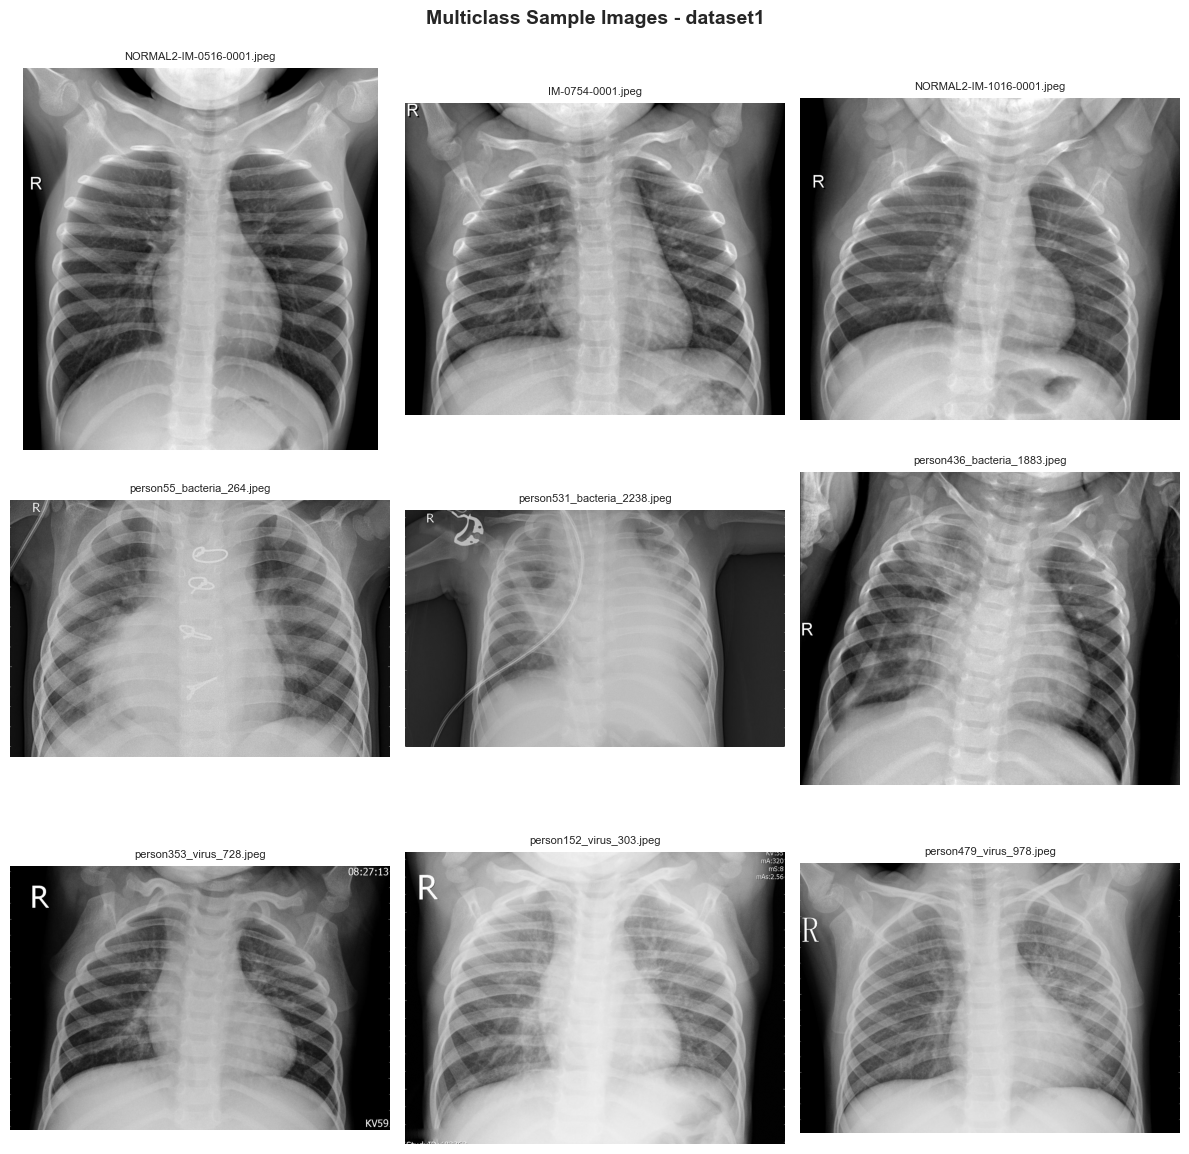

✓ Multiclass sample visualization saved to: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\reports\figures\multiclass_samples_dataset1.png

Visualizing multiclass samples from: dataset2


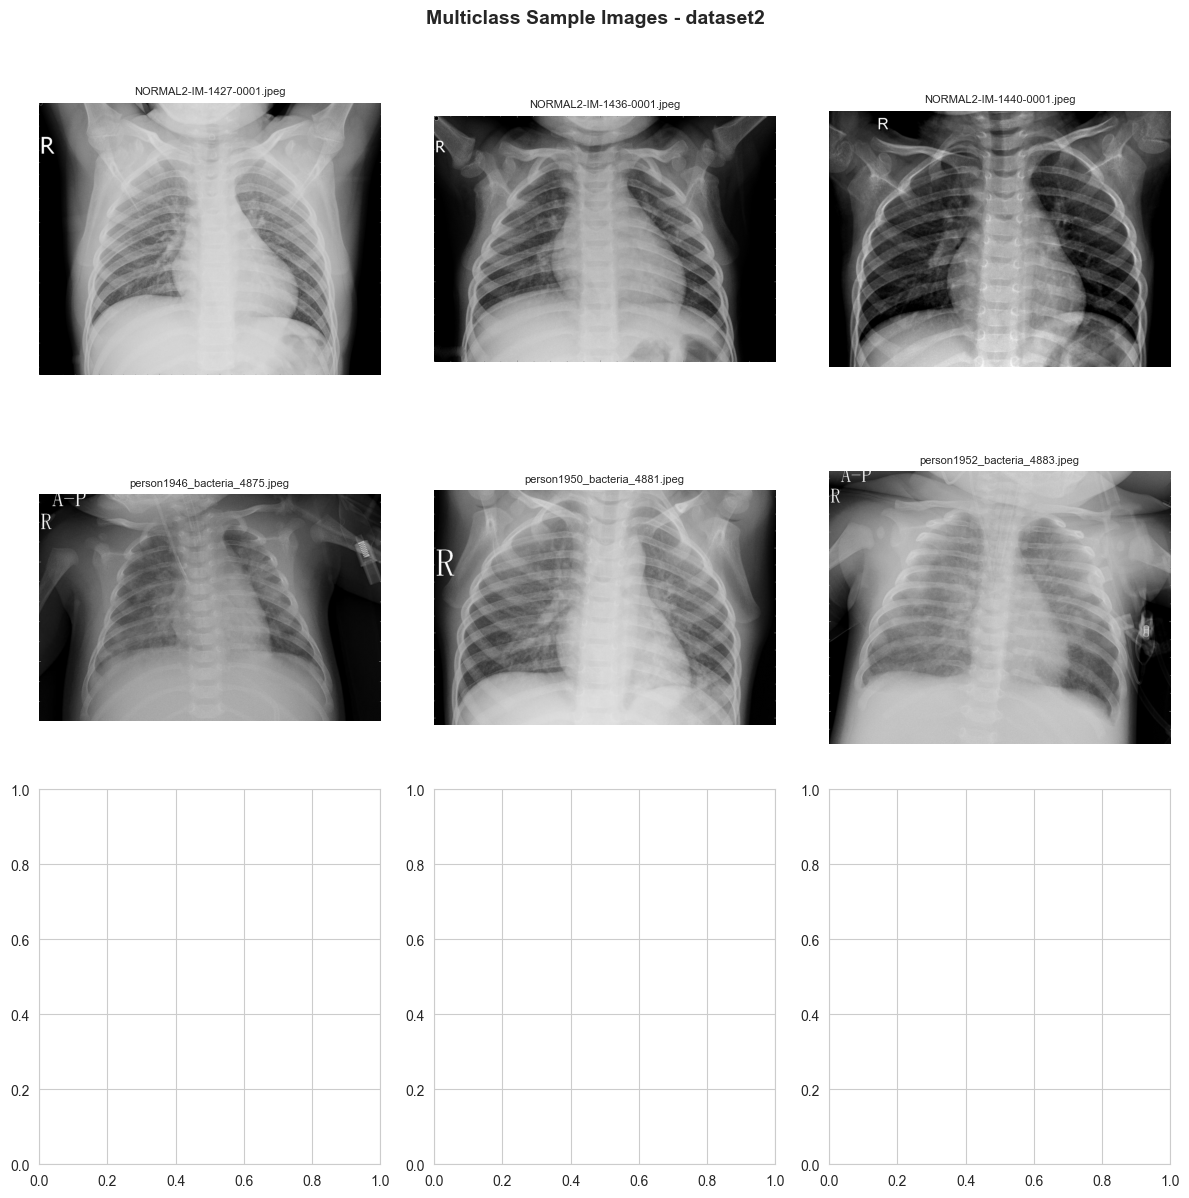

✓ Multiclass sample visualization saved to: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\reports\figures\multiclass_samples_dataset2.png

Visualizing multiclass samples from: dataset3_tuning


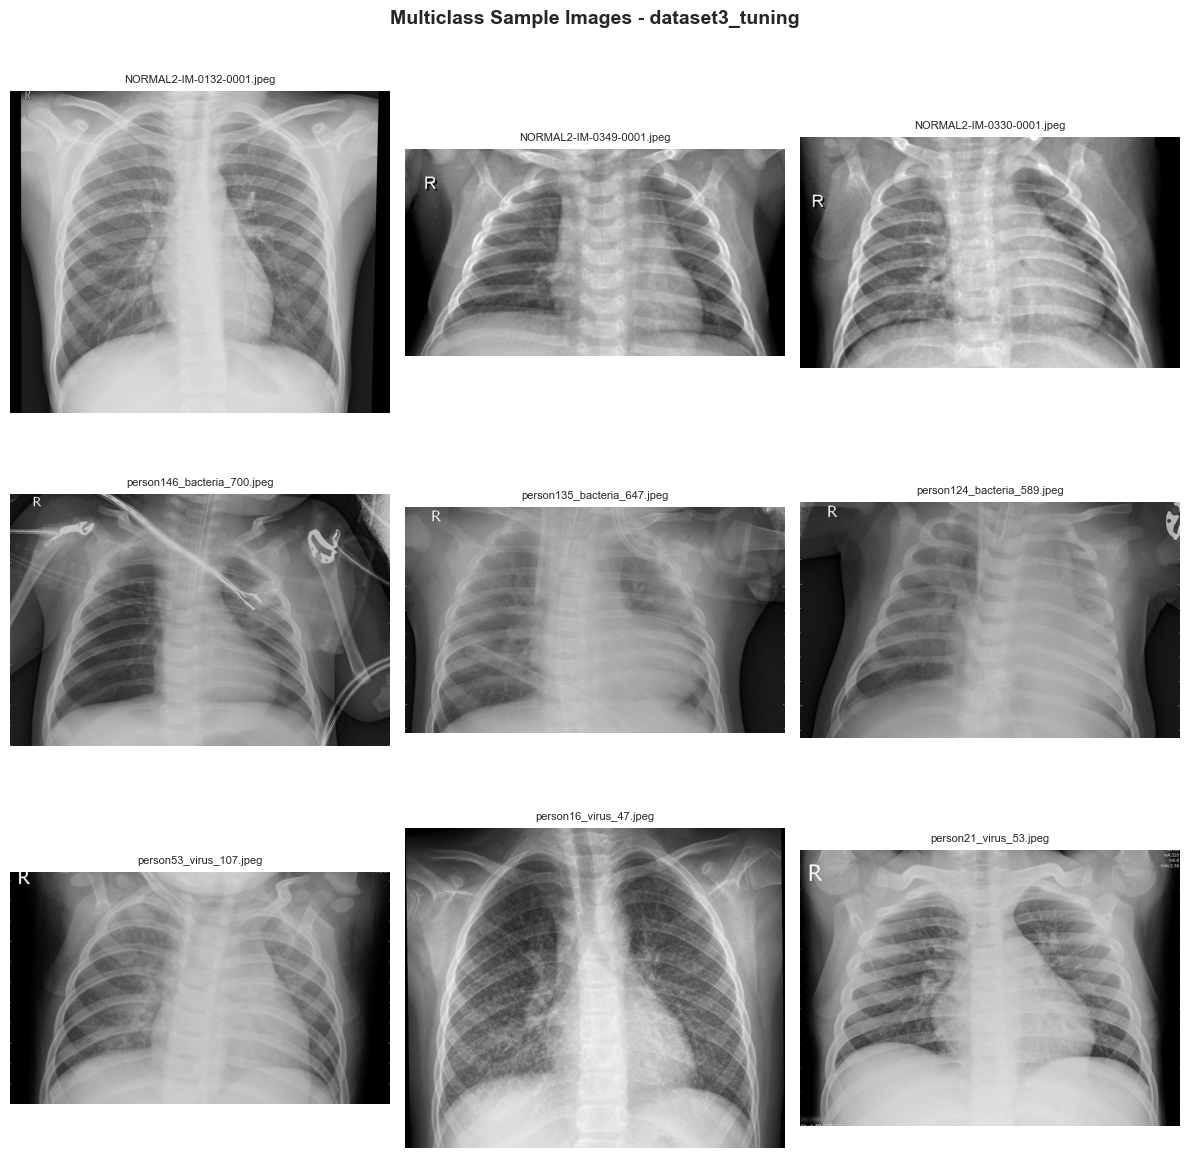

✓ Multiclass sample visualization saved to: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\reports\figures\multiclass_samples_dataset3_tuning.png


In [14]:
def visualize_multiclass_samples(dataset_path, dataset_name, samples_per_class=3):
    """
    Visualize samples using real multiclass labels:
    NORMAL / BACTERIA / VIRUS
    """
    print(f"\nVisualizing multiclass samples from: {dataset_name}")
    
    if not dataset_path.exists():
        print("⚠️  Dataset path does not exist.")
        return
    
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
    class_images = {'NORMAL': [], 'BACTERIA': [], 'VIRUS': []}
    
    class_dirs = [d for d in dataset_path.iterdir() if d.is_dir()]
    
    for class_dir in class_dirs:
        class_name = class_dir.name.upper()
        images = [f for f in class_dir.rglob('*')
                 if f.is_file() and f.suffix.lower() in image_extensions]
        
        for img_path in images:
            filename = img_path.name.upper()
            
            if 'NORMAL' in class_name:
                class_images['NORMAL'].append(img_path)
            elif 'BACTERIA' in filename or 'BACTERIAL' in filename:
                class_images['BACTERIA'].append(img_path)
            elif 'VIRUS' in filename or 'VIRAL' in filename:
                class_images['VIRUS'].append(img_path)
    
    fig, axes = plt.subplots(3, samples_per_class, figsize=(4 * samples_per_class, 12))
    
    for i, (label, images) in enumerate(class_images.items()):
        if len(images) == 0:
            continue
        
        sampled = np.random.choice(images, size=min(samples_per_class, len(images)), replace=False)
        
        for j in range(samples_per_class):
            ax = axes[i, j]
            
            if j < len(sampled):
                try:
                    img = Image.open(sampled[j])
                    img_array = np.array(img)
                    
                    if len(img_array.shape) == 2:
                        ax.imshow(img_array, cmap='gray')
                    else:
                        ax.imshow(img_array)
                    
                    ax.set_title(sampled[j].name[:30], fontsize=8)
                except Exception as e:
                    ax.text(0.5, 0.5, f"Error\n{e}", ha='center', va='center')
            else:
                ax.axis('off')
            
            if j == 0:
                ax.set_ylabel(label, fontweight='bold', fontsize=12)
            
            ax.axis('off')
    
    plt.suptitle(f'Multiclass Sample Images - {dataset_name}', fontweight='bold', fontsize=14, y=0.995)
    plt.tight_layout()
    
    save_path = project_root / 'reports' / 'figures' / f'multiclass_samples_{dataset_name}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Multiclass sample visualization saved to: {save_path}")

    
for name, path in dataset_paths.items():
 visualize_multiclass_samples(path, name, samples_per_class=3)

---
## 5. Data Quality Report

Generating a comprehensive data quality report.

In [15]:
def generate_data_quality_report(dataset_structures, integrity_results, real_label_results):
    """
    Generate a comprehensive data quality report.

    Includes:
    - Physical folder structure
    - Real binary label distribution
    - Real multiclass label distribution
    - Integrity checks
    - Recommendations for next preprocessing/modeling steps
    """
    report = []
    report.append("=" * 80)
    report.append("ZOIDBERG2.0 - DATA QUALITY REPORT")
    report.append("=" * 80)
    report.append(f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
    report.append("")

    # Overall Summary
    report.append("OVERALL SUMMARY")
    report.append("-" * 80)

    total_images = sum(
        s['total_images'] for s in dataset_structures.values()
        if s and s['exists']
    )
    total_corrupted = sum(
        r['corrupted'] for r in integrity_results.values()
        if r is not None
    )
    total_unknown_multiclass = sum(
        r['unknown_multiclass'] for r in real_label_results.values()
        if r is not None
    )

    report.append(f"Total Images Across All Datasets: {total_images}")
    report.append(f"Total Corrupted Images (sample-based): {total_corrupted}")
    report.append(f"Total Unknown Multiclass Labels: {total_unknown_multiclass}")
    report.append("")

    # Per-Dataset Details
    for name in dataset_structures.keys():
        structure = dataset_structures.get(name)
        integrity = integrity_results.get(name)
        real_labels = real_label_results.get(name)

        report.append(f"\n{name.upper()}")
        report.append("-" * 80)

        if structure and structure['exists']:
            report.append(f"Path: {structure['path']}")
            report.append(f"Total Images: {structure['total_images']}")

            # Physical folder structure
            report.append(f"\nPhysical Folder Classes: {len(structure['classes'])}")
            if structure['classes']:
                report.append("Physical Folder Distribution:")
                for cls, count in structure['classes'].items():
                    percentage = (count / structure['total_images']) * 100 if structure['total_images'] > 0 else 0
                    report.append(f"  • {cls}: {count} ({percentage:.1f}%)")

            # Real labels
            if real_labels:
                total_real = real_labels['total_images']

                report.append("\nReal Binary Label Distribution:")
                for cls, count in real_labels['binary_distribution'].items():
                    percentage = (count / total_real) * 100 if total_real > 0 else 0
                    report.append(f"  • {cls}: {count} ({percentage:.1f}%)")

                report.append("\nReal Multiclass Label Distribution:")
                for cls, count in real_labels['multiclass_distribution'].items():
                    percentage = (count / total_real) * 100 if total_real > 0 else 0
                    report.append(f"  • {cls}: {count} ({percentage:.1f}%)")

                report.append(f"\nUnknown Multiclass Labels: {real_labels['unknown_multiclass']}")

                if real_labels['unknown_multiclass'] > 0 and real_labels['unknown_examples']:
                    report.append("Examples of unknown filenames:")
                    for ex in real_labels['unknown_examples']:
                        report.append(f"  • {ex}")

                # Explicit interpretation
                report.append("\nInterpretation:")
                report.append("  • Physical folders may suggest a binary structure (NORMAL / PNEUMONIA).")
                report.append("  • However, filenames reveal the true medical subclasses used for multiclass learning.")
                report.append("  • This dataset can therefore support both:")
                report.append("      - Binary classification: NORMAL vs PNEUMONIA")
                report.append("      - Multiclass classification: NORMAL vs BACTERIA vs VIRUS")

            # Integrity
            if integrity:
                report.append(f"\nIntegrity Check (sample of {integrity['sampled']}):")
                report.append(f"  • Corrupted: {integrity['corrupted']}")
                report.append(f"  • Color Modes: {', '.join(integrity['color_modes'].keys())}")

                if integrity['dimensions']:
                    widths = [d[0] for d in integrity['dimensions']]
                    heights = [d[1] for d in integrity['dimensions']]
                    report.append(
                        f"  • Dimension Range: {min(widths)}x{min(heights)} to {max(widths)}x{max(heights)}"
                    )

        else:
            report.append("⚠️  Dataset not found or empty")

    # Recommendations
    report.append("\n" + "=" * 80)
    report.append("RECOMMENDATIONS")
    report.append("=" * 80)

    if total_images == 0:
        report.append("⚠️  ACTION REQUIRED: No datasets found. Please:")
        report.append("   1. Place your X-ray datasets in the appropriate directories")
        report.append("   2. Organize images into class subdirectories (e.g., NORMAL, PNEUMONIA)")
        report.append("   3. Ensure Dataset3 is reserved for hyperparameter tuning")
    else:
        report.append("✓ Datasets detected. Proceeding with analysis...")

        if total_corrupted > 0:
            report.append(f"⚠️  Found {total_corrupted} corrupted images in sampled checks.")
            report.append("   Consider removing them before preprocessing.")

        if total_unknown_multiclass > 0:
            report.append(f"⚠️  Found {total_unknown_multiclass} images with unknown multiclass labels.")
            report.append("   Check filename conventions or exclude ambiguous samples.")

        # Physical folder imbalance
        for name, structure in dataset_structures.items():
            if structure and structure['classes']:
                counts = list(structure['classes'].values())
                if len(counts) > 1 and min(counts) > 0:
                    imbalance = max(counts) / min(counts)
                    if imbalance > 2:
                        report.append(f"⚠️  {name}: Physical folder imbalance detected (ratio {imbalance:.2f}:1)")

        # Real multiclass imbalance
        for name, real_labels in real_label_results.items():
            if real_labels:
                counts = [v for v in real_labels['multiclass_distribution'].values() if v > 0]
                if len(counts) > 1:
                    imbalance = max(counts) / min(counts)
                    if imbalance > 2:
                        report.append(f"⚠️  {name}: Real multiclass imbalance detected (ratio {imbalance:.2f}:1)")
                        report.append("   Consider class weighting, resampling, or macro-averaged metrics.")

        report.append("\nNEXT STEP GUIDANCE")
        report.append("-" * 80)
        report.append("✓ Step 2 should support multiclass preprocessing.")
        report.append("✓ Labels should be extracted from both folder names and filenames.")
        report.append("✓ The pipeline should preserve the 3 real medical classes when multiclass=True.")
        report.append("✓ Binary and multiclass experiments can both be compared in later notebooks.")

        report.append("\n✓ Ready to proceed to Step 2: Preprocessing & Feature Engineering")

    report.append("\n" + "=" * 80)

    # Print report
    report_text = "\n".join(report)
    print(report_text)

    # Save report with UTF-8 encoding
    report_path = project_root / 'reports' / 'data_quality_report.txt'
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report_text)

    print(f"\n✓ Report saved to: {report_path}")

    return report_text


# Generate report
quality_report = generate_data_quality_report(
    dataset_structures,
    integrity_results,
    real_label_results
)

ZOIDBERG2.0 - DATA QUALITY REPORT
Generated: 2026-03-30 16:14:22

OVERALL SUMMARY
--------------------------------------------------------------------------------
Total Images Across All Datasets: 5856
Total Corrupted Images (sample-based): 0
Total Unknown Multiclass Labels: 0


DATASET1
--------------------------------------------------------------------------------
Path: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\data\raw\dataset1
Total Images: 5216

Physical Folder Classes: 2
Physical Folder Distribution:
  • NORMAL: 1341 (25.7%)
  • PNEUMONIA: 3875 (74.3%)

Real Binary Label Distribution:
  • NORMAL: 1341 (25.7%)
  • PNEUMONIA: 3875 (74.3%)

Real Multiclass Label Distribution:
  • NORMAL: 1341 (25.7%)
  • BACTERIA: 2530 (48.5%)
  • VIRUS: 1345 (25.8%)

Unknown Multiclass Labels: 0

Interpretation:
  • Physical folders may suggest a binary structure (NORMAL / PNEUMONIA).
  • However, filenames reveal the true medical subclasses used for multiclass learning

---
## 6. Next Steps

### Completed:
- ✓ Dataset structure analysis
- ✓ Class distribution analysis
- ✓ Image integrity checks
- ✓ Sample visualization
- ✓ Data quality report generation

### Ready for Step 2: Preprocessing & Feature Engineering

In the next notebook (`02_Preprocessing_FeatureEngineering.ipynb`), we will:
1. Image preprocessing pipeline (resizing, normalization)
2. Data augmentation strategy
3. Feature extraction
4. PCA for dimensionality reduction
5. Train-test split vs Cross-validation setup
6. Save preprocessed data for modeling

---

**Note:** Before proceeding, ensure that:
- All three datasets are properly placed in their respective directories
- Images are organized in class subdirectories
- Dataset3 is reserved for hyperparameter tuning only